# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
      We use GLMs, latent variable models, and activation functions when the outcome is not best modeled by a simple straight-line relationship. They are especially useful for things like binary outcomes, categories, or probabilities. Their main advantage over ordinary linear models is that they can handle nonlinear relationships between the linear predictor and the final output, and they can produce valid probabilities between 0 and 1.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
   Binary and categorical cross entropy work well because they match the kind of probability model logistic regression assumes. In binary logistic regression, the outcome follows a Bernoulli setup, and in multiclass logistic regression it follows a categorical setup. Minimizing cross entropy is the same as choosing the coefficients that make the observed data most likely, and it also penalizes predictions that are very confident and wrong.

3. True or false, and explain: Logistic regression is a linear model.
   True, logistic regression is linear in the predictors through the linear combination of the features and coefficients. However, it is not linear in the predicted probability itself, because that linear combination is passed through a logistic function to turn it into a probability.
4. True or false, and explain: Logistic regression cannot be used for classification.
   False, logistic regression is commonly used for classification. It first predicts probabilities, and then those probabilities can be turned into class labels, such as predicting class 1 when the probability is above 0.5.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
   No, not directly. In logistic regression, a coefficient represents the change in the log-odds for a one-unit increase in the feature, not the direct change in predicted probability. The actual change in probability depends on where you are starting, so it is not constant.
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
   False. Feature engineering is still important in logistic regression. Even though the final probability comes from a nonlinear function, the model is still based on a linear combination of the chosen features.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
   False. Logistic regression is better when the outcome is categorical, especially for binary classification. Ordinary least squares is still the right choice when the outcome is continuous. One model is not always better than the other and it depends on the type of response variable and the goal of the analysis.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


2.1

In [5]:
# Load data
q2 = pd.read_csv("data/data.csv", sep=";")
print(q2.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

In [6]:
q2_cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target",
]
q2 = q2[q2_cols]
q2.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [7]:
print(q2.isna().sum())
q2["dropout"] = (q2["Target"] == "Dropout").astype(int)

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


There were no missing values for the columns relevant to the question. 

2.2

In [8]:
x_bin = q2[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y_bin = q2["dropout"]

logit_bin = LogisticRegression()
logit_bin.fit(x_bin, y_bin)

coef_table = pd.DataFrame({
    "feature": x_bin.columns,
    "coefficient": logit_bin.coef_[0],
}).sort_values("coefficient", ascending=False)

print(coef_table.to_string(index=False))

                feature  coefficient
                 Debtor     0.530625
      Age at enrollment     0.049925
     Scholarship holder    -1.227442
Tuition fees up to date    -2.556542


Based off the coefficient signs, debtor and age at enrollment have a higher dropout probability whereas tuition fees up to date and scholarship holder have a lower dropout probability. There is a large negative coefficient so yes, being up to date on tuition strongly reduces estimated dropout ris.

2.3

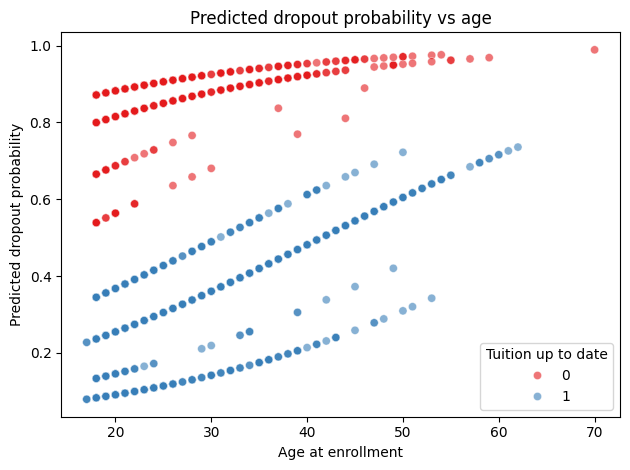

In [9]:
q2["p_dropout_logit"] = logit_bin.predict_proba(x_bin)[:, 1]

plt.figure()
sns.scatterplot(
    data=q2,
    x="Age at enrollment",
    y="p_dropout_logit",
    hue="Tuition fees up to date",
    alpha=0.6,
    s=35,
    palette="Set1",
)
plt.title("Predicted dropout probability vs age")
plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.legend(title="Tuition up to date")
plt.tight_layout()
plt.show()

Based off the graph, it looks like tuition being up to date lowers the predicted dropout probability for most younger ot middle ages, with the largest average drop in the first three age quartiles. It looks like on average, the marginal change is around 0.50 in predicted dropout probability. 

2.4

In [10]:
y_pred_bin = logit_bin.predict(x_bin)
cm_bin = confusion_matrix(y_bin, y_pred_bin)
acc_bin = accuracy_score(y_bin, y_pred_bin)

print(cm_bin)
print("Accuracy:" , acc_bin)


[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


2.5

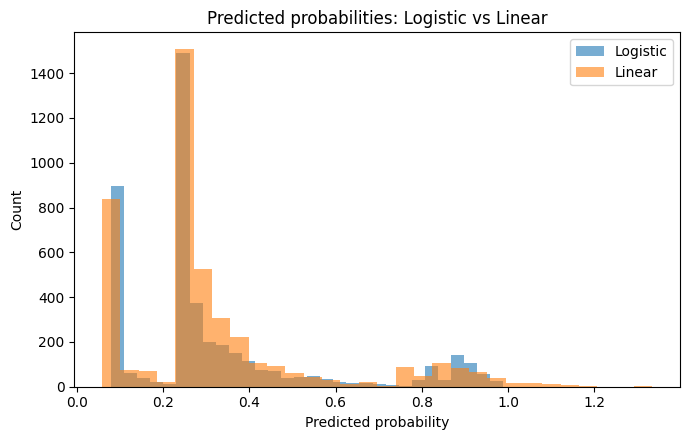

In [11]:
lin = LinearRegression()
lin.fit(x_bin, y_bin)
q2["p_dropout_linear"] = lin.predict(x_bin)

plt.figure(figsize=(7, 4.5))
plt.hist(q2["p_dropout_logit"], bins=30, alpha=0.6, label="Logistic")
plt.hist(q2["p_dropout_linear"], bins=30, alpha=0.6, label="Linear")
plt.title("Predicted probabilities: Logistic vs Linear")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Logistic and linear models have very similar accuracy, although on average, the linear predicted probabilities are slightly lower than that of the logistic when comparing the counts. 

2.6

Most at-risk students are more likely to have debt, not be up to date on tuition, and be slightly older. 

Some useful interventions might include targeted financial aid/payment plans and early tutoring/academic supports.

2.7

In [12]:
x_multi = q2[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = q2["Target"]

logit_multi = LogisticRegression()
logit_multi.fit(x_multi, y_multi)

y_pred_multi = logit_multi.predict(x_multi)
cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=logit_multi.classes_)
proba_multi = logit_multi.predict_proba(x_multi)

print(pd.DataFrame(cm_multi, index=logit_multi.classes_, columns=logit_multi.classes_))
print("\nClasses predicted by hard classification:", sorted(pd.Series(y_pred_multi).unique()))
print("Classes with positive probability in predict_proba:", list(logit_multi.classes_))

          Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Classes predicted by hard classification: ['Dropout', 'Graduate']
Classes with positive probability in predict_proba: ['Dropout', 'Enrolled', 'Graduate']


In multinomial logistic classification, hard predictions only produced `Dropout` and `Graduate` classes in this fit, but `predict_proba` assigned non-zero probability to all classes (`Dropout`, `Enrolled`, `Graduate`).

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

2.1

In [17]:
q3 = pd.read_csv("data/cirrhosis.csv")
q3_cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
q3 = q3[q3_cols].copy()
print(q3.head())
print(len(q3))

   Bilirubin Edema             Drug  Stage Status
0       14.5     Y  D-penicillamine    4.0      D
1        1.1     N  D-penicillamine    3.0      C
2        1.4     S  D-penicillamine    4.0      D
3        1.8     S  D-penicillamine    4.0      D
4        3.4     N          Placebo    3.0     CL
418


In [18]:
print(q3.isna().sum())

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


Rows with missing values were dropped (missingness was present in `Drug` and `Stage`).

In [19]:
q3 = q3.dropna().copy()
print(len(q3))

312


In [20]:
q3["survived"] = q3["Status"].isin(["C", "CL"]).astype(int)

2.2

In [21]:
x_surv = pd.get_dummies(q3[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y_surv = q3["survived"]

logit_surv = LogisticRegression()
logit_surv.fit(x_surv, y_surv)

coef_surv = pd.DataFrame({
    "feature": x_surv.columns,
    "coefficient": logit_surv.coef_[0],
}).sort_values("coefficient", ascending=False)

print(coef_surv.to_string(index=False))

     feature  coefficient
Drug_Placebo     0.231225
   Bilirubin    -0.351424
     Edema_S    -0.450677
     Edema_Y    -1.611049


Higher bilirubin predicts lower survival probability (negative coefficient). Relative to no edema, edema categories reduce survival probability (negative coefficients). The placebo indicator is positive relative to the dropped drug baseline in this encoding, suggesting somewhat higher survival for placebo.

2.3

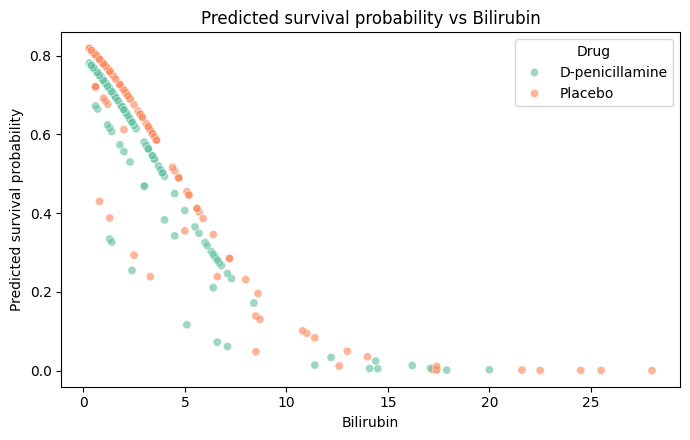

In [22]:
q3["p_survival_logit"] = logit_surv.predict_proba(x_surv)[:, 1]

plt.figure(figsize=(7, 4.5))
sns.scatterplot(
    data=q3,
    x="Bilirubin",
    y="p_survival_logit",
    hue="Drug",
    alpha=0.65,
    s=35,
    palette="Set2",
)
plt.title("Predicted survival probability vs Bilirubin")
plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.tight_layout()
plt.show()

Predicted survival generally decreases as bilirubin rises. However, the drug seems to be the most effective at mid to higher dosages.

2.4

In [23]:
y_pred_surv = logit_surv.predict(x_surv)
cm_surv = confusion_matrix(y_surv, y_pred_surv)
acc_surv = accuracy_score(y_surv, y_pred_surv)

print(cm_surv)
print(f"Accuracy:" ,acc_surv)

[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


2.5

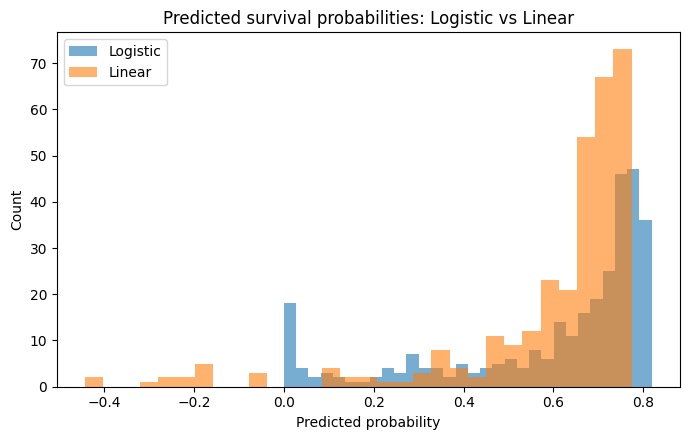

In [24]:
lin_surv = LinearRegression()
lin_surv.fit(x_surv, y_surv)
q3["p_survival_linear"] = lin_surv.predict(x_surv)

plt.figure(figsize=(7, 4.5))
plt.hist(q3["p_survival_logit"], bins=30, alpha=0.6, label="Logistic")
plt.hist(q3["p_survival_linear"], bins=30, alpha=0.6, label="Linear")
plt.title("Predicted survival probabilities: Logistic vs Linear")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

The linear model produces some invalid negative probabilities, and on average, the predicted probability of the linear model appears to be slightly lower. 

2.6

In [25]:
x_stage = pd.get_dummies(q3[["Edema", "Bilirubin"]], drop_first=True)
y_stage = q3["Stage"].astype(str)

logit_stage = LogisticRegression()
logit_stage.fit(x_stage, y_stage)

y_pred_stage = logit_stage.predict(x_stage)
cm_stage = confusion_matrix(y_stage, y_pred_stage, labels=logit_stage.classes_)
proba_stage = logit_stage.predict_proba(x_stage)

print("\nPart 6: Multinomial confusion matrix for Stage")
print(pd.DataFrame(cm_stage, index=logit_stage.classes_, columns=logit_stage.classes_))
print("\nClasses predicted by hard classification:", sorted(pd.Series(y_pred_stage).unique()))
print("Classes with positive probability in predict_proba:", list(logit_stage.classes_))


Part 6: Multinomial confusion matrix for Stage
     1.0  2.0  3.0  4.0
1.0    0    0   16    0
2.0    0    0   63    4
3.0    0    0  105   15
4.0    0    0   79   30

Classes predicted by hard classification: ['3.0', '4.0']
Classes with positive probability in predict_proba: ['1.0', '2.0', '3.0', '4.0']


For multinomial prediction of `Stage`, hard predictions only returned classes `3.0` and `4.0`, while `predict_proba` still provided non-zero probabilities for all four stages (`1.0`, `2.0`, `3.0`, `4.0`).

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

### Q4 Answers
1. For the linear model,
$$
\hat{y}=\beta_0+\sum_{k=1}^K \beta_k x_k,
$$
so
$$
\frac{\partial \hat{y}}{\partial x_k}=\beta_k.
$$
So basically, if $x_k$ goes up by 1 (and everything else stays the same), the prediction changes by exactly $\beta_k$.

2. For logistic regression,
$$
\hat{p}=\frac{e^{\beta^T x}}{1+e^{\beta^T x}},
$$
and using chain rule,
$$
\frac{\partial \hat{p}}{\partial x_k}=\hat{p}(1-\hat{p})\beta_k.
$$
This means the effect is not constant like in linear regression. It depends on the current value of $\hat{p}$.
The effect is biggest when $\hat{p}=0.5$, since $\hat{p}(1-\hat{p})$ is largest there (equal to $1/4$).
So near $\hat{p}=0.5$, we can say
$$
\frac{\partial \hat{p}}{\partial x_k}\approx \frac{1}{4}\beta_k,
$$
so $4\frac{\partial \hat{p}}{\partial x_k}\approx\beta_k$.

3. In log-odds form,
$$
\log\left(\frac{\hat{p}}{1-\hat{p}}\right)=\beta_0+\sum_{k=1}^K\beta_k x_k.
$$
So a 1-unit increase in $x_k$ increases log-odds by $\beta_k$ (holding other features fixed).
Another way to say that: the odds get multiplied by $e^{\beta_k}$.